In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [36]:
FILE_PATH = 'advertising.csv'

In [37]:
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# Bài 1: Chia dữ liệu thành X và y

In [38]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [39]:
X

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [40]:
y

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [41]:
class LinearRegresion:
    # Hàm khởi tạo ban đầu
    def __init__(self,batch_size = 1,epochs = 100, lr = 1e-5,shuffle = False):
        self.w, self.b = (None , None)
        # Số sample lấy ra mỗi lần huấn luyện và cập nhật trọng số mô hình [32,64,128,256]
        self.batch_size = batch_size
        # Số lần học toàn bộ dữ liệu của mô hình
        self.epochs = epochs
        # Tham số lr - learning rate- tốc độ học của mô hình
        self.lr = lr
        # Tham số quy định mỗi epoch có quyết định xáo trộn dữ liệu hay không
        self.shuffle = shuffle
        
    # Hàm dự đoán của mô hình
    def predict(self,X):
        return X@self.w + self.b
    # Hàm tính đạo hàm của Loss theo w
    def dL_dw(self,y_pred, y,x):
        return 2*(y_pred-y)*x

    # hàm tính đạo hàm của Loss theo b
    def dL_db(self, y_pred, y):
        return 2*(y_pred-y)

    # Hàm tính Loss funtion của mô hình
    def Loss_function(self,y_pred,y):
        return np.mean((y_pred- y )**2)
        
    # Hàm huấn luyện mô hình
    def fit(self,X, y):
        self.data_train = np.append(X,y.reshape(-1,1),axis=1)
        # Mảng random các trọng số w1, w2, .., wn và b của mô hình
        rdw = np.random.uniform(-1,1,size = X.shape[1] +1)
        #self.w, self.b = rdw[:-1], rdw[-1]

        # ---- Đoạn này fix trọng số khởi tạo w và b do làm bài tập để tiện so sánh kết quả ---------
        fix = np.array([0.016992259082509283 , 0.0070783670518262355 ,-0.002307860847821344 , 0])
        self.w, self.b = fix[:-1], fix[-1]
        #--------------------------------------------------------------------------------------------
        
        self.Losses = []
        for epoch in range(self.epochs):
            # Nếu mà shuffle == True --> Mỗi epoch --> tiến hành random toàn bộ dữ liệu huấn luyện
            if self.shuffle: np.random.shuffle(self.data_train)
            Loss = [ ] # Loss của mỗi epoch
            for i in range(0,self.data_train.shape[0],self.batch_size):
                # Lô - batch -số lượng sample lấy ra huấn luyện mô hình mỗi lần
                batch = self.data_train[i:i+self.batch_size]
                # mảng dL_dw: [dL_dw1, dL_dw2, .., dL_dwn] và dL_db --> Để tính trung bình dL_dw và dL_db do mỗi sample --> dL_dw và dL_db 
                avg_dL_dw =  np.zeros(self.w.shape)
                avg_dL_db = 0
                for sample in batch:
                    x_train , y_train = sample[:-1], sample[-1]
                    y_pred = self.predict(x_train)
                    avg_dL_dw += self.dL_dw(y_pred,y_train,x_train)
                    avg_dL_db += self.dL_db(y_pred,y_train)
                # tính trung bình dL_dw và dL_db --> nếu data_train.shape[0] % batch_size != 0 
                # --> tính TB dL_dw, dL_db phải chia số lượng sample mà batch lấy được
                avg_dL_dw /= batch.shape[0]
                avg_dL_db /= batch.shape[0]

                # Cập nhật trọng số w và b của mô hình
                self.w -= self.lr*avg_dL_dw
                self.b -= self.lr*avg_dL_db

                # Mảng dự đoán các sample  trong batch
                y_pred_batch = self.predict(batch[:,:-1])
                # Mảng các giá trị thật trong batch
                y_batch = batch[:,-1]
                Loss.append(self.Loss_function(y_pred_batch,y_batch))
            Loss = sum(Loss)/len(Loss)
            self.Losses.append(Loss)
            print(f"epoch {epoch + 1:<5} ==== Loss = {Loss:<20} ======= w = {str(self.w):<50} ====== b = {str(self.b):<20}")

# Lấy ra các thông tin cơ, thống kê cơ bản của bộ dữ liệu

In [42]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [44]:
X, y = X.to_numpy(), y.to_numpy()

# Làm bài tập 
- với w khởi tạo cố w1 , w2 , w3 , b = (0.016992259082509283 , 0.0070783670518262355 ,-0.002307860847821344 , 0)
- lr = 1e-5
- epochs = 50
- batch_size = 1
- shuffle = False
- Dự đoán mẩu sample sau [TV= 19.2, Radio = 35.9, Newspaper = 51.3]

In [45]:
rg = LinearRegresion(epochs=50)

In [46]:
rg.fit(X,y)

epoch 1     ==== Loss = 5.231071535813168    ======= w = [0.07562837 0.11137259 0.04211573]                 ====== b = 0.004213169669934351
epoch 2     ==== Loss = 4.015574296006462    ======= w = [0.07503497 0.13940359 0.02973535]                 ====== b = 0.00722822167751816 
epoch 3     ==== Loss = 3.9160891507375055   ======= w = [0.07478888 0.15123229 0.02332318]                 ====== b = 0.010102546546902224
epoch 4     ==== Loss = 3.902927670900375    ======= w = [0.07467447 0.15642036 0.02044726]                 ====== b = 0.012924871971619935
epoch 5     ==== Loss = 3.9012163892308163   ======= w = [0.07461741 0.15869457 0.01916783]                 ====== b = 0.01572374084859187 
epoch 6     ==== Loss = 3.899954670954372    ======= w = [0.07458565 0.15968232 0.01859498]                 ====== b = 0.018511356742686544
epoch 7     ==== Loss = 3.898012050683067    ======= w = [0.07456507 0.16010179 0.01833432]                 ====== b = 0.02129309577223291 
epoch 8     ==== Los

In [47]:
# Dự báo cho mẩu data cho trước 
X_test = np.array([19.2,35.9,51.3])

In [48]:
rg.predict(X_test)

np.float64(8.176413319549823)

In [55]:
# Sử dụng Toàn bộ sample để huấn luyện và cập nhật trọng số
# epochs = 1000
# batch_size = số sample của training data
rg = LinearRegresion(epochs=1000,batch_size=X.shape[0])

In [56]:
rg.fit(X,y)

epoch 1     ==== Loss = 39.40816747451342    ======= w = [0.05950217 0.01340834 0.00568528]                 ====== b = 0.0002507551798622155
epoch 2     ==== Loss = 18.15746728564735    ======= w = [0.07621641 0.01654262 0.00943986]                 ====== b = 0.00036866040528805196
epoch 3     ==== Loss = 14.634633779162359   ======= w = [0.08268682 0.01840047 0.01150004]                 ====== b = 0.0004336565365827102
epoch 4     ==== Loss = 13.913880074022755   ======= w = [0.0850908  0.01974438 0.01287659]                 ====== b = 0.0004774995117943194
epoch 5     ==== Loss = 13.640049637323438   ======= w = [0.08588207 0.02087731 0.01397117]                 ====== b = 0.0005128053963177648
epoch 6     ==== Loss = 13.441395294810784   ======= w = [0.08603526 0.02191971 0.01494351]                 ====== b = 0.0005445875522229761
epoch 7     ==== Loss = 13.259118517018987   ======= w = [0.08593745 0.02291949 0.01585722]                 ====== b = 0.0005748393911486764
epoch 8     

# Chia dữ liệu tập train - test

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
# Khởi tạo mô hình
rg = LinearRegresion(epochs=200, lr = 0.01, batch_size = 128, shuffle=True)

In [59]:
# Huấn luyện mô hình
# Do không chuẩn hóa dữ liệu + lr quá lớn -> tình trạng overflow
rg.fit(X_train,y_train)

epoch 1     ==== Loss = 11940847178097.236   ======= w = [-27286.65845742  -2661.28316156  -4547.55559493]  ====== b = -139.94957558371996 
epoch 2     ==== Loss = 2.2759358952941267e+24 ======= w = [-1.12545512e+10 -1.30564588e+09 -1.59823270e+09]  ====== b = -54549147.66876383  
epoch 3     ==== Loss = 5.84081478153216e+35 ======= w = [-5.23457304e+15 -5.35321168e+14 -6.70788845e+14]  ====== b = -23825854376200.445 
epoch 4     ==== Loss = 6.19069327156104e+46 ======= w = [-1.96640848e+21 -2.29833520e+20 -3.00414300e+20]  ====== b = -1.0050816045764618e+19
epoch 5     ==== Loss = 1.1109437446575507e+58 ======= w = [-7.95768021e+26 -8.72624653e+25 -1.21819197e+26]  ====== b = -4.003947285275042e+24
epoch 6     ==== Loss = 1.8657611722956688e+69 ======= w = [-3.17790163e+32 -4.89652808e+31 -7.27009063e+31]  ====== b = -1.5809550877199632e+30
epoch 7     ==== Loss = 4.1000156240734864e+80 ======= w = [-1.43906168e+38 -1.55970284e+37 -1.60948821e+37]  ====== b = -6.61566975420632e+35
epo

C:\Users\chien\AppData\Local\Temp\ipykernel_15672\1614592287.py:27: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred- y )**2)
C:\Users\chien\anaconda3\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\chien\AppData\Local\Temp\ipykernel_15672\1614592287.py:55: RuntimeWarning: overflow encountered in add
  avg_dL_dw += self.dL_dw(y_pred,y_train,x_train)
C:\Users\chien\AppData\Local\Temp\ipykernel_15672\1614592287.py:19: RuntimeWarning: invalid value encountered in multiply
  return 2*(y_pred-y)*x
C:\Users\chien\AppData\Local\Temp\ipykernel_15672\1614592287.py:63: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr*avg_dL_dw


# Chuẩn hóa dữ liệu trước khi huấn luyện mô hình

In [60]:
scaler = MinMaxScaler()

In [61]:
X = scaler.fit_transform(X)

In [62]:
X[:5]

array([[0.77578627, 0.76209677, 0.60598065],
       [0.1481231 , 0.79233871, 0.39401935],
       [0.0557998 , 0.92540323, 0.60686016],
       [0.50997633, 0.83266129, 0.51187335],
       [0.60906324, 0.21774194, 0.51099384]])

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
# Khởi tạo mô hình
rg = LinearRegresion(epochs=400,lr = 0.01, batch_size=128,shuffle=True)

In [65]:
# Huấn luyện mô hình
rg.fit(X_train,y_train)

epoch 1     ==== Loss = 250.60359581369534   ======= w = [0.39926169 0.31691835 0.16069364]                 ====== b = 0.6173452693359727  
epoch 2     ==== Loss = 212.23984475165963   ======= w = [0.74124331 0.59559804 0.32785685]                 ====== b = 1.1825962709199083  
epoch 3     ==== Loss = 191.28559603562917   ======= w = [1.0662801  0.8781206  0.47129732]                 ====== b = 1.7178821816315835  
epoch 4     ==== Loss = 159.8087514724923    ======= w = [1.34740978 1.11200529 0.59552247]                 ====== b = 2.2024316517577778  
epoch 5     ==== Loss = 147.49765330111012   ======= w = [1.62633687 1.34366531 0.71497959]                 ====== b = 2.6641679212024862  
epoch 6     ==== Loss = 126.81386084514764   ======= w = [1.8829166  1.55410484 0.82029325]                 ====== b = 3.092803353633477   
epoch 7     ==== Loss = 116.43594143603576   ======= w = [2.13362547 1.75429112 0.93474131]                 ====== b = 3.499987198710206   
epoch 8     ==== Los

# Dự đoán mô hình

In [66]:
y_pred = rg.predict(X_test)

In [67]:
print(f"Lỗi của mô hình: {mean_squared_error(y_pred,y_test)}")

Lỗi của mô hình: 4.628329649625913


In [69]:
y_pred_train = rg.predict(X_train)

In [70]:
print(f"Lỗi của mô hình trên tập training: {mean_squared_error(y_pred_train,y_train)}")

Lỗi của mô hình trên tập training: 3.888354661323605


# Vẽ loss trong quá trình training

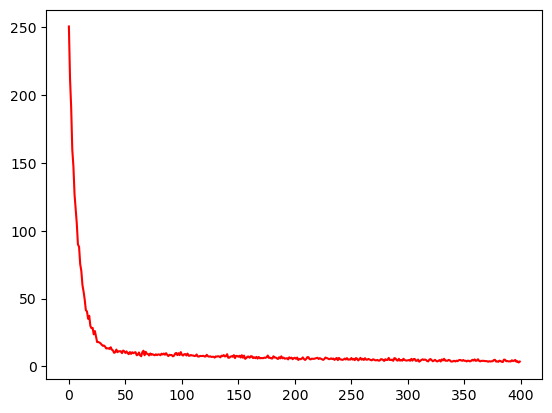

In [71]:
plt.plot(rg.Losses,'r')